### Baseline Model on Main Application Table

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    for path in candidates:
        if (path / "notebooks").exists() or (path / "src").exists() or (path / "data").exists():
            return path
    return start

def find_data_dir(project_root):
    candidates = [
        project_root / "data" / "raw",
        project_root / "data" / "sample",
        Path("/mnt/data"),
        project_root,
    ]

    for path in candidates:
        if (path / "application_train.csv").exists() and (path / "application_test.csv").exists():
            return path

    raise FileNotFoundError("Could not find application_train.csv and application_test.csv")

PROJECT_ROOT = find_project_root()
DATA_DIR = find_data_dir(PROJECT_ROOT)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
SUBMISSION_DIR = OUTPUT_DIR / "submissions"

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "application_train.csv"
TEST_PATH = DATA_DIR / "application_test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_PATH exists:", TRAIN_PATH.exists())
print("TEST_PATH exists:", TEST_PATH.exists())
print("SAMPLE_SUB_PATH exists:", SAMPLE_SUB_PATH.exists())

PROJECT_ROOT: c:\Coding\Home-Credit-Default-Risk
DATA_DIR: c:\Coding\Home-Credit-Default-Risk\data\raw
TRAIN_PATH exists: True
TEST_PATH exists: True
SAMPLE_SUB_PATH exists: True


In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

if SAMPLE_SUB_PATH.exists():
    sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
else:
    sample_sub = pd.DataFrame({"SK_ID_CURR": test["SK_ID_CURR"], "TARGET": 0.0})

print("Train shape:", train.shape)
print("Test shape :", test.shape)

for df in [train, test]:
    df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

print("DAYS_EMPLOYED anomaly handled.")
print("Train anomaly count:", train["DAYS_EMPLOYED_ANOM"].sum())
print("Test anomaly count :", test["DAYS_EMPLOYED_ANOM"].sum())

print("\nTARGET distribution:")
print(train["TARGET"].value_counts().sort_index())
print("\nTARGET proportion:")
print(train["TARGET"].value_counts(normalize=True).sort_index())

display(train.head())
display(test.head())
display(sample_sub.head())

Train shape: (307511, 122)
Test shape : (48744, 121)
DAYS_EMPLOYED anomaly handled.
Train anomaly count: 55374
Test anomaly count : 9274

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET proportion:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637.0000,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,"-1,188.0000","-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225.0000,"-4,260.0000",

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM
0,100001,Cash loans,F,N,Y,0,"135,000.0000","568,800.0000","20,560.5000","450,000.0000",Unaccompanied,Working,Higher education,Married,House / apartment,0.0188,-19241,"-2,329.0000","-5,170.0000",-812,NaN,1,1,0,1,0,1,NaN,2.0000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.7526,0.7897,0.1595,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0000,0.0000,0.0000,0.0000,"-1,740.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0
1,100005,Cash loans,M,N,Y,0,"99,000.0000","222,768.0000","17,370.0000","180,000.0000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.0358,-18064,"-4,469.0000","-9,118.0000",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.5650,0.2917,0.4330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,0
2,100013,Cash loans,M,Y,Y,0,"202,500.0000","663,264.0000","69,777.0000","630,000.0000",NaN,Working,Higher education,Married,House / apartment,0.0191,-20038,"-4,458.0000","-2,175.0000",-3503,5.0000,1,1,0,1,0,0,Drivers,2.0000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.6998,0.6110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.000

,SK_ID_CURR,TARGET
0,100001,0.5000
1,100005,0.5000
2,100013,0.5000
3,100028,0.5000
4,100038,0.5000


In [4]:
ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"

X = train.drop(columns=[TARGET_COL, ID_COL]).copy()
y = train[TARGET_COL].copy()
X_test = test.drop(columns=[ID_COL]).copy()
test_ids = test[ID_COL].copy()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Number of features:", X.shape[1])
print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))

print("\nCategorical columns:")
print(categorical_cols)

Number of features: 121
Number of categorical columns: 16
Number of numeric columns: 105

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [5]:
for df in [X, X_test]:
    for col in categorical_cols:
        df[col] = df[col].fillna("MISSING").astype(str)

print("Categorical missing values replaced with 'MISSING'.")
display(X[categorical_cols].head())

Categorical missing values replaced with 'MISSING'.


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,MISSING,MISSING,MISSING,MISSING
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,MISSING,MISSING,MISSING,MISSING
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,MISSING,MISSING,MISSING,MISSING


In [6]:
positive_count = int(y.sum())

# For tiny sample data, use fewer folds.
# For full Kaggle data, this will naturally use 5 folds.
n_splits = 3 if positive_count < 10 else 5

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
feature_importance_list = []

print("Positive class count:", positive_count)
print("Using n_splits =", n_splits)

Positive class count: 24825
Using n_splits = 5


In [7]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_cols,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=50
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_valid, valid_pred)

    oof_preds[valid_idx] = valid_pred
    test_preds += test_pred / n_splits
    fold_scores.append(fold_auc)

    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.get_feature_importance(),
        "fold": fold
    })
    feature_importance_list.append(fold_importance)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

Fold 1 AUC: 0.755092
Fold 2 AUC: 0.765237
Fold 3 AUC: 0.758302
Fold 4 AUC: 0.765160
Fold 5 AUC: 0.755821


In [8]:
overall_auc = roc_auc_score(y, oof_preds)

print("Fold AUC scores:", [round(score, 6) for score in fold_scores])
print("Mean fold AUC :", round(np.mean(fold_scores), 6))
print("OOF AUC       :", round(overall_auc, 6))

oof_df = train[[ID_COL, TARGET_COL]].copy()
oof_df["OOF_PRED"] = oof_preds

display(oof_df.head(10))

Fold AUC scores: [0.755092, 0.765237, 0.758302, 0.76516, 0.755821]
Mean fold AUC : 0.759922
OOF AUC       : 0.759895


,SK_ID_CURR,TARGET,OOF_PRED
0,100002,1,0.9006
1,100003,0,0.3144
2,100004,0,0.3212
3,100006,0,0.4427
4,100007,0,0.5662
5,100008,0,0.4550
6,100009,0,0.1043
7,100010,0,0.2273
8,100011,0,0.3742
9,100012,0,0.2461


In [9]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    "TARGET": test_preds
})

submission_path = SUBMISSION_DIR / "baseline_main_table_catboost.csv"
submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
display(submission.head())

Submission saved to: c:\Coding\Home-Credit-Default-Risk\outputs\submissions\baseline_main_table_catboost.csv


,SK_ID_CURR,TARGET
0,100001,0.2811
1,100005,0.6266
2,100013,0.1738
3,100028,0.2887
4,100038,0.6586


,feature,importance
39,EXT_SOURCE_3,16.5932
38,EXT_SOURCE_2,11.2240
37,EXT_SOURCE_1,7.1000
1,AMT_CREDIT,5.6048
22,DAYS_BIRTH,4.9031
2,AMT_GOODS_PRICE,4.6450
0,AMT_ANNUITY,4.5031
23,DAYS_EMPLOYED,3.4117
25,DAYS_ID_PUBLISH,2.1415
89,NAME_EDUCATION_TYPE,2.0908


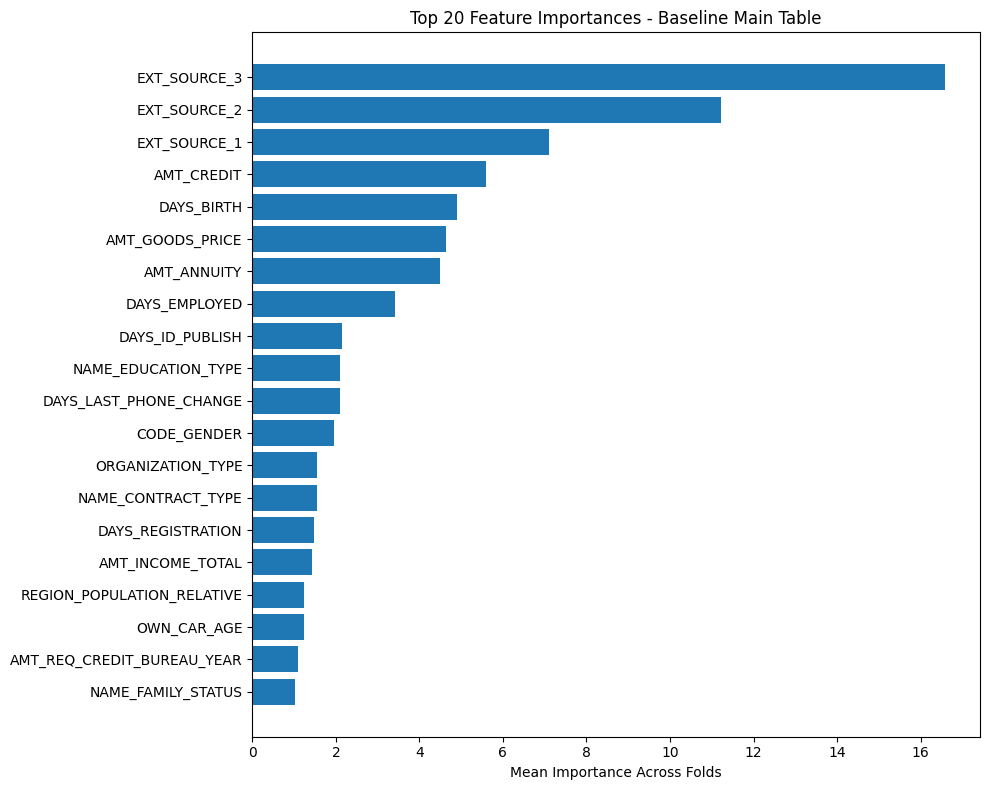

Figure saved to: c:\Coding\Home-Credit-Default-Risk\outputs\figures\baseline_main_table_feature_importance.png


In [10]:
feature_importance = (
    pd.concat(feature_importance_list, axis=0)
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
)

display(feature_importance.head(20))

top_n = 20
plot_df = feature_importance.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 Feature Importances - Baseline Main Table")
plt.xlabel("Mean Importance Across Folds")
plt.tight_layout()

fig_path = FIG_DIR / "baseline_main_table_feature_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", fig_path)

In [11]:
report_lines = [
    "# Baseline Results",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Positive rate: {y.mean():.4f}",
    f"- Number of categorical columns: {len(categorical_cols)}",
    f"- Number of numeric columns: {len(numeric_cols)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {n_splits}",
    f"- Fold AUC scores: {[round(score, 6) for score in fold_scores]}",
    f"- Mean fold AUC: {np.mean(fold_scores):.6f}",
    f"- OOF AUC: {overall_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- Feature importance figure: {fig_path}",
    "",
    "## Notes",
    "- This baseline uses only the main application table.",
    "- This benchmark will be compared against later feature-engineered models.",
]

report_path = REPORT_DIR / "baseline_results.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Report saved to:", report_path)

Report saved to: c:\Coding\Home-Credit-Default-Risk\outputs\reports\baseline_results.md
